# 1. Generate 2D dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

2026-05-14 12:15:42.080824: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def Show_data2D(x):
    plt.plot(np.arange(L),x[0, :, 0], label='sample 0', c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 0], label='sample 1', c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 0], label='sample 2', c='b')
    plt.plot(np.arange(L),x[0, :, 1], c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 1], c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 1], c='b')
    
    plt.legend()
    plt.title("Time series")
    plt.show()

In [3]:
# random seed for reproducibility
np.random.seed(12345)

jump = lambda drift, std: int(np.random.normal(drift, std))
# rumore non lineare????

In [4]:
def pattern(i,z,a):
    return int(a*np.cos((np.pi*i)/z))

In [5]:
def build_model(L, n_class=3, NF=5, kernel_size=11, l2_reg=0.2, stddev=0.05):
    
    input_shape = (L, 1)
    
    reg = tf.keras.regularizers.l2(l2_reg)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
    model = Sequential([
        Conv1D(filters=NF, kernel_size=kernel_size,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               padding='same',
               activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=NF * 2, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )


    return model


In [ ]:
SNRs = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 5, 10, 15]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []

for SNR in SNRs:
    sigma = np.linspace(20, 200, 5)
    for s in sigma:
        A = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * s
        pattern_params.append( (A, s) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 100

for params in pattern_params:
    
    y = [0] * N 
    x = [[0] * L for i in range(N)] 
    
    for i in range(N):
       
        if i>0: 
            x[i][0] = x[i-1][-1] + jump(bias,params[1]) 
        
        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,params[1]) 
            
        y[i] = i%3 
    
        if y[i]>0:
            j0 = np.random.randint(0,L-1-d) 
            sign = 3-2*y[i] 
            for j in range(d): 
                x[i][j0+j] += sign*pattern(j,d,params[0]) 
    
    model = build_model(L)

    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    x_val = np.array(x_val)
    y_val = np.array(y_val)     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    x_train = (x_train - xm_train[:, None]) / std_train[:, None]
    x_val   = (x_val   - xm_val[:, None])   / std_val[:, None]
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val   = x_val.reshape(x_val.shape[0], L, 1)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
        
    print(f"Done for {params[0]}, {params[1]}")
    


[0, 0, 0, 0, 0, 0.5, 0.5, 0.5, 0.5, 0.5, 1, 1, 1, 1, 1, 1.5, 1.5, 1.5, 1.5, 1.5, 2, 2, 2, 2, 2, 2.5, 2.5, 2.5, 2.5, 2.5, 3, 3, 3, 3, 3, 3.5, 3.5, 3.5, 3.5, 3.5, 5, 5, 5, 5, 5, 10, 10, 10, 10, 10, 15, 15, 15, 15, 15]
[0.3475     0.33399999 0.34599999 0.33450001 0.354      0.354
 0.37799999 0.38249999 0.36649999 0.39300001 0.55400002 0.55949998
 0.44549999 0.56800002 0.6455     0.70599997 0.72850001 0.73449999
 0.76499999 0.75349998 0.75650001 0.81       0.80549997 0.82499999
 0.81400001 0.866      0.903      0.91049999 0.88800001 0.90149999
 0.92449999 0.92650002 0.93849999 0.93000001 0.93699998 0.94700003
 0.958      0.949      0.949      0.95050001 0.98549998 0.97899997
 0.97649997 0.96649998 0.98650002 0.99349999 0.99699998 0.99449998
 0.99849999 0.99599999 0.99849999 0.99699998 0.99849999 0.99650002
 0.99849999]


[]

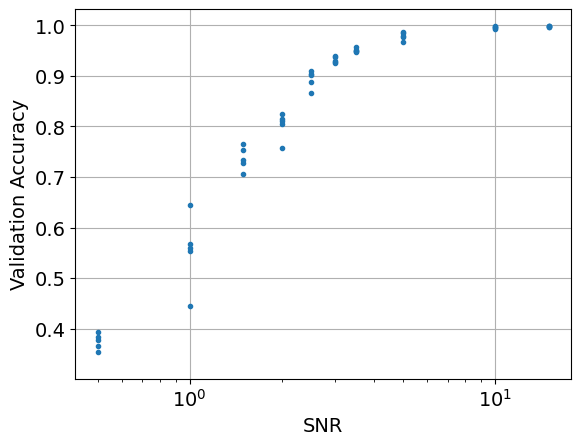

In [49]:
accuracy = np.array(acc)
SNRs = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 5, 10, 15]

tmp = [i for i in SNRs for j in range(5)]

with open("accuracy.pkl", "rb") as f:
    accuracy = pickle.load(f)

pattern_params = np.array(pattern_params)

print(tmp)
print(accuracy)

fig, ax = plt.subplots()
ax.plot(tmp, accuracy, ".")
ax.set_xlabel("SNR")
ax.set_ylabel("Validation Accuracy")
ax.grid()
plt.semilogx()

In [27]:
import pickle
"""
# salvataggio su file
with open("accuracy.pkl", "wb") as f:
    pickle.dump(accuracy, f)
    """

In [51]:
SNRs = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 5, 10, 15]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = np.linspace(20, 200, 5)
tmp = [s for s in sigma for _ in range(5)]
sigma = np.array(tmp)

for SNR in SNRs:
    
    for s in sigma:
        A = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * s
        pattern_params.append( (A, s) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 100

for params in pattern_params:
    
    y = [0] * N 
    x = [[0] * L for i in range(N)] 
    
    for i in range(N):
       
        if i>0: 
            x[i][0] = x[i-1][-1] + jump(bias,params[1]) 
        
        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,params[1]) 
            
        y[i] = i%3 
    
        if y[i]>0:
            j0 = np.random.randint(0,L-1-d) 
            sign = 3-2*y[i] 
            for j in range(d): 
                x[i][j0+j] += sign*pattern(j,d,params[0]) 
    
    model = build_model(L)

    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    x_val = np.array(x_val)
    y_val = np.array(y_val)     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    x_train = (x_train - xm_train[:, None]) / std_train[:, None]
    x_val   = (x_val   - xm_val[:, None])   / std_val[:, None]
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val   = x_val.reshape(x_val.shape[0], L, 1)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
        
    print(f"Done for {params[0]}, {params[1]}")
    


Done for 0.0, 20.0
Done for 0.0, 20.0
Done for 0.0, 20.0
Done for 0.0, 20.0
Done for 0.0, 20.0
Done for 0.0, 65.0
Done for 0.0, 65.0
Done for 0.0, 65.0
Done for 0.0, 65.0
Done for 0.0, 65.0
Done for 0.0, 110.0
Done for 0.0, 110.0
Done for 0.0, 110.0
Done for 0.0, 110.0
Done for 0.0, 110.0
Done for 0.0, 155.0
Done for 0.0, 155.0
Done for 0.0, 155.0
Done for 0.0, 155.0
Done for 0.0, 155.0
Done for 0.0, 200.0
Done for 0.0, 200.0
Done for 0.0, 200.0
Done for 0.0, 200.0
Done for 0.0, 200.0
Done for 31.834575763634692, 20.0
Done for 31.834575763634692, 20.0
Done for 31.834575763634692, 20.0
Done for 31.834575763634692, 20.0
Done for 31.834575763634692, 20.0
Done for 103.46237123181275, 65.0
Done for 103.46237123181275, 65.0
Done for 103.46237123181275, 65.0
Done for 103.46237123181275, 65.0
Done for 103.46237123181275, 65.0
Done for 175.09016669999082, 110.0
Done for 175.09016669999082, 110.0
Done for 175.09016669999082, 110.0
Done for 175.09016669999082, 110.0
Done for 175.09016669999082, 1

In [52]:
accuracy_snr_3 = np.array(acc)

print(np.std(accuracy_snr_3))
print(np.std(accuracy[-5:]))

0.23376963325806913
0.0008717740346508906


In [53]:
"""
with open("accuracy_each_sample.pkl", "wb") as f:
    pickle.dump(accuracy_snr_3, f)
"""

In [86]:
accuracy_reshaped = np.reshape(accuracy_snr_3, (55, 5))
accuracy_mean = np.mean(accuracy_reshaped, axis=1)
accuracy_std = np.std(accuracy_reshaped, axis=1)

In [113]:
abs_mean = np.mean(np.reshape(accuracy_mean, (11, 5)), axis=1)
abs_std = np.std(np.reshape(accuracy_mean, (11, 5)), axis=1)/5**0.5

chi = 0

for g in range(11):
    chi_group = 0
    for i in range(5):
        chi += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2 + abs_std[g]**2)
        chi_group += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2)
    print(chi_group)

print(chi)

0.512705687309645
1.1588900451163835
7.000214108713937
0.16205735836249532
2.7636967344541956
8.262413007484113
2.999284356716418
1.8196408131388768
7.614180687963902
4.100093723426321
2.94061185903489
28.96247717216138


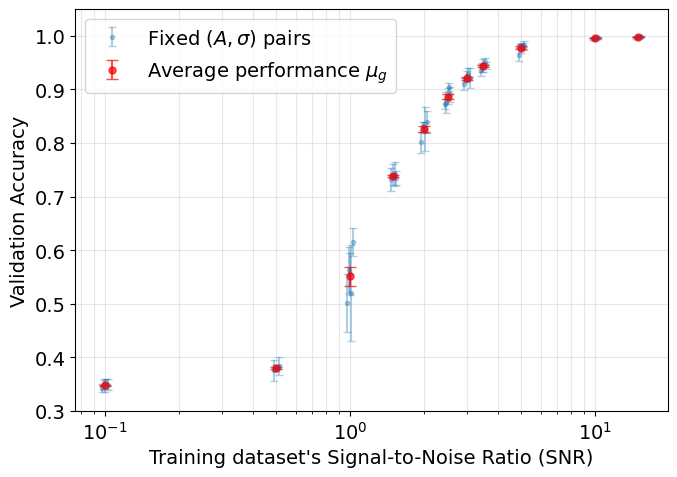

In [132]:
fig, ax = plt.subplots(figsize=(7,5))

# jitter leggero per evitare overlap
tmp = [
    snr * (1 + delta)
    for snr in SNRs
    for delta in np.linspace(-0.025, 0.025, 5)
]

# risultati delle singole configurazioni
ax.errorbar(
    tmp,
    accuracy_mean,
    yerr=accuracy_std,
    fmt='.',
    capsize=3,
    alpha=0.35,
    label='Fixed $(A,\\sigma)$ pairs'
)

# media globale
ax.errorbar(
    SNRs,
    abs_mean,
    yerr=abs_std,
    fmt='o',
    color="red",
    capsize=4,
    linewidth=1.5,
    markersize=5,
    label=r'Average performance $\mu_g$',
    alpha=0.7
    
)

# asse logaritmico
ax.set_xscale('log')

# labels
ax.set_xlabel("Training dataset's Signal-to-Noise Ratio (SNR)")
ax.set_ylabel("Validation Accuracy")

# limiti utili
ax.set_ylim(0.3, 1.05)

# griglia leggibile
ax.grid(True, which="both", alpha=0.3)

# legenda
ax.legend()

plt.tight_layout()
plt.savefig("accuracy_plot.png", bbox_inches="tight")
plt.show()

# Jack compila da qui in poi

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [4]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [ ]:
SNRs = [0.1, 0.3, 1, 3, 10, 30]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20


for SNR in SNRs:
    SNR_partition = np.linspace(0, 1, 5)
    for s in SNR_partition:
        A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
        A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
        #mu_1, mu_2 = np.random.randint(0, 100, 2)
        for _ in range(5):
            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 100


for params in pattern_params:
    
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
   
    A1, DX1, bias1, A2, DX2, bias2 = params 
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
        
                    # 1 -> + +
                    # 2 -> - -
                """elif y[i]<5:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    sign = 3-2*(y[i]-2)
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 3 -> + +
                    # 4 -> + -
                else:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 5 -> - -
      
                  """
    #Show_data2D(x)
    model = BM.build_model(L, n_class=n_class)

    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
        
    print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])}")
    


In [9]:
accuracy_2D = np.array(acc)
import pickle
with open("accuracy_2D.pkl", "wb") as f:
    pickle.dump(accuracy_2D, f)


In [ ]:
print(accuracy_2D)

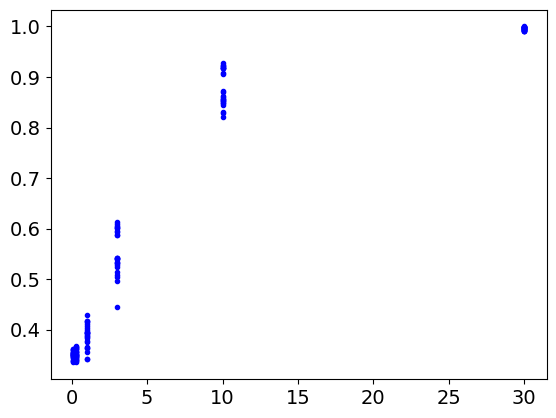

In [10]:
pattern_params = np.array(pattern_params)

# Now your calculation will work perfectly
snr_g = np.pi**3 / (2 * (np.pi + 4) * d * sigma**2) * (pattern_params[:, 0]**2 + pattern_params[:, 3]**2)

plt.plot(snr_g, accuracy_2D, "b.")

In [11]:
accuracy_reshaped = np.reshape(accuracy_2D, (30, 5))
accuracy_mean = np.mean(accuracy_reshaped, axis=1)
accuracy_std = np.std(accuracy_reshaped, axis=1)

[0.3502  0.3516  0.38786 0.55284 0.87748 0.99578]
0.9971248628162233
0.5449445805263757
10.923900762383754
16.331730253211724
19.913196509829067
11.88321877275185
60.59411574151899


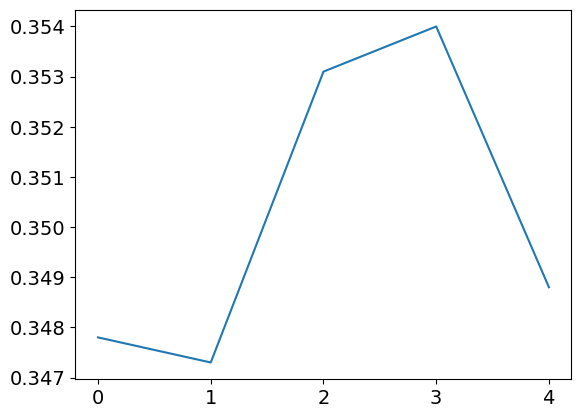

In [22]:
abs_mean = np.mean(np.reshape(accuracy_mean, (6, 5)), axis=1)
abs_std = np.std(np.reshape(accuracy_mean, (6, 5)), axis=1)/5**0.5

chi = 0

plt.plot(range(5), np.reshape(accuracy_mean, (6, 5))[0])
print(abs_mean)
for g in range(6):
    chi_group = 0
    for i in range(5):
        chi += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2 + abs_std[g]**2)
        chi_group += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2 + abs_std[g]**2)
    print(chi_group)

print(chi)

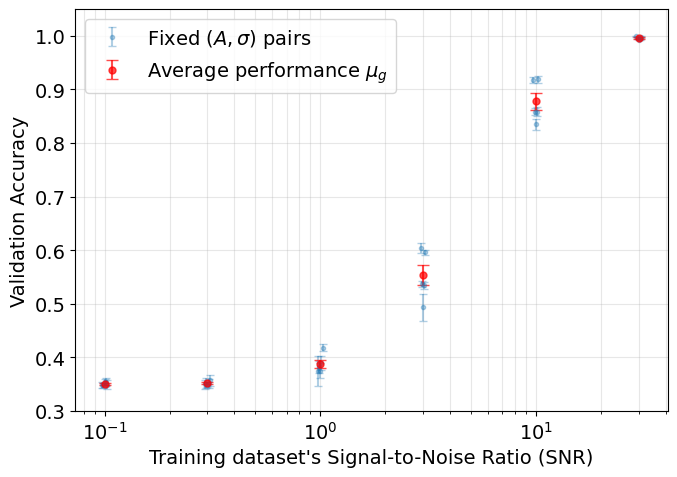

In [13]:
fig, ax = plt.subplots(figsize=(7,5))
SNRs = [0.1, 0.3, 1, 3, 10, 30]

# jitter leggero per evitare overlap
tmp = [
    snr * (1 + delta)
    for snr in SNRs
    for delta in np.linspace(-0.025, 0.025, 5)
]

# risultati delle singole configurazioni
ax.errorbar(
    tmp,
    accuracy_mean,
    yerr=accuracy_std,
    fmt='.',
    capsize=3,
    alpha=0.35,
    label='Fixed $(A,\\sigma)$ pairs'
)

# media globale
ax.errorbar(
    SNRs,
    abs_mean,
    yerr=abs_std,
    fmt='o',
    color="red",
    capsize=4,
    linewidth=1.5,
    markersize=5,
    label=r'Average performance $\mu_g$',
    alpha=0.7
    
)

# asse logaritmico
ax.set_xscale('log')

# labels
ax.set_xlabel("Training dataset's Signal-to-Noise Ratio (SNR)")
ax.set_ylabel("Validation Accuracy")

# limiti utili
ax.set_ylim(0.3, 1.05)

# griglia leggibile
ax.grid(True, which="both", alpha=0.3)

# legenda
ax.legend()

plt.tight_layout()
plt.savefig("accuracy_plot.png", bbox_inches="tight")
plt.show()

In [ ]:


#1. SNR log scale (SNRs = [0.1, 0.3, 1, 3, 10, 30]) (SNR trainning)
#2. train 1 model for each (high number of epochs)
#3. dataset with SNR log scale (SNR test)
#4. study the accuracy of each model on each dataset

# heat map
#           |----------------------------|
#           |                            |
# acc test  |                            |
#           |                            |
#           |                            |
#           |----------------------------|
#                       acc train

